# EDA: 2023 Retrosheet steal-attempt data

Sanity-checks the output of `src/retrosheet_parser.py` before we build
anything on top of it. The goal here is purely **"is the data good?"** —
no modeling, no decision layer.

We already know a few 2023 facts from public sources, so we can check the
parsed data against them:

- Ronald Acuña Jr. led MLB in stolen bases in 2023 with **73**.
- League-wide stolen-base success rate in 2023 was **~80%** (a big jump from
  prior years because of the new pickoff-limit / bigger-base rules).
- Every steal attempt should resolve to a real runner on base.


In [1]:
import pandas as pd

steals = pd.read_csv("../data/sample/steals_2023.csv")
print(steals.shape)
steals.head()


(4439, 20)


,game_id,date,park,inning,half,outs,target_base,runner_id,runner_bats,pitcher_id,catcher_id,batter_id,count,score_bat,score_def,score_diff,on_1b,on_2b,on_3b,success
0,HOU202310160,2023/10/16,HOU03,3,0,2,2,tavel001,B,montr004,maldm001,semim001,10,5,1,4,tavel001,NaN,NaN,1
1,TEX202310190,2023/10/19,ARL03,7,0,0,2,abrej003,R,smitw002,heimj001,tuckk001,12,7,3,4,abrej003,NaN,NaN,1
2,TEX202310200,2023/10/20,ARL03,8,1,2,2,tavel001,B,presr001,maldm001,lowen001,1,4,2,2,tavel001,NaN,carte001,1
3,HOU202310220,2023/10/22,HOU03,1,1,0,2,altuj001,R,eovan001,heimj001,branm003,22,0,0,0,altuj001,NaN,NaN,1
4,HOU202310220,2023/10/22,HOU03,8,0,0,2,carte001,L,abreb002,maldm001,garca005,10,3,2,1,carte001,NaN,NaN,1


## 1. Shape, dtypes, date range — does this look like a full season?

In [2]:
print(f"rows: {len(steals)}")
print(f"date range: {steals['date'].min()} to {steals['date'].max()}")
print(f"unique games: {steals['game_id'].nunique()}")
print(f"unique runners: {steals['runner_id'].nunique()}")
steals.dtypes


rows: 4439
date range: 2023/03/30 to 2023/11/01
unique games: 1938
unique runners: 493


game_id        object
date           object
park           object
inning          int64
half            int64
outs            int64
target_base    object
runner_id      object
runner_bats    object
pitcher_id     object
catcher_id     object
batter_id      object
count           int64
score_bat       int64
score_def       int64
score_diff      int64
on_1b          object
on_2b          object
on_3b          object
success         int64
dtype: object

## 2. Every attempt resolves to a runner?

If the parser lost track of base occupancy, `runner_id` would be null for
some steal attempts. It shouldn't be.


In [3]:
missing_runner = steals["runner_id"].isna().sum()
print(f"attempts with no resolved runner: {missing_runner} / {len(steals)}")
assert missing_runner == 0


attempts with no resolved runner: 0 / 4439


## 3. League-wide success rate — should be close to 80% for 2023.

In [4]:
success_rate = steals["success"].mean()
print(f"league SB success rate: {success_rate:.1%}")
sb = steals["success"].sum()
cs = len(steals) - sb
print(f"SB: {sb}   CS: {cs}   total attempts: {len(steals)}")


league SB success rate: 80.2%
SB: 3561   CS: 878   total attempts: 4439


## 4. Stolen bases per player, 2023 — leaderboard cross-check

This is the most direct sanity check: sum up successful steals per
`runner_id` and see if the top of the list matches what actually happened
in 2023. Acuña should be #1 with 73.


In [5]:
sb_by_player = (
    steals[steals["success"] == 1]
    .groupby("runner_id")
    .size()
    .sort_values(ascending=False)
)
sb_by_player.head(15)


runner_id
acunr001    75
ruize001    65
carrc005    59
wittb002    49
abrac001    47
hoern001    43
kim-h002    38
rodrj007    37
stotb001    36
delae003    34
turnt001    34
lowej002    32
lindf001    31
castw003    31
tuckk001    30
dtype: int64

In [6]:
acuna = sb_by_player.get("acunr001")
print(f"Acuna Jr. (acunr001) stolen bases: {acuna}")
assert sb_by_player.index[0] == "acunr001"
assert acuna >= 70


Acuna Jr. (acunr001) stolen bases: 75


## 5. Attempts per player too (success rate isn't the whole picture)

A player can have a great SB total but a mediocre success rate if they run
a lot. Combine both.


In [7]:
attempts_by_player = steals.groupby("runner_id").size()
success_by_player = steals.groupby("runner_id")["success"].mean()

leaderboard = pd.DataFrame({
    "sb": sb_by_player,
    "attempts": attempts_by_player,
}).fillna(0)
leaderboard["cs"] = leaderboard["attempts"] - leaderboard["sb"]
leaderboard["success_rate"] = leaderboard["sb"] / leaderboard["attempts"]
leaderboard.sort_values("sb", ascending=False).head(15)


,sb,attempts,cs,success_rate
runner_id,,,,
acunr001,75.0,89,14.0,0.842697
ruize001,65.0,78,13.0,0.833333
carrc005,59.0,65,6.0,0.907692
wittb002,49.0,64,15.0,0.765625
abrac001,47.0,51,4.0,0.921569
hoern001,43.0,50,7.0,0.860000
kim-h002,38.0,47,9.0,0.808511
rodrj007,37.0,47,10.0,0.787234
stotb001,36.0,39,3.0,0.923077


## 6. Target base breakdown

Stealing second should be by far the most common attempt; third much
rarer; home very rare. Success rate should drop as the target base gets
harder (2nd easiest, home hardest).


In [8]:
base_summary = steals.groupby("target_base").agg(
    attempts=("success", "size"),
    success_rate=("success", "mean"),
).sort_values("attempts", ascending=False)
base_summary


,attempts,success_rate
target_base,,
2,3780,0.800000
3,610,0.840984
H,49,0.489796


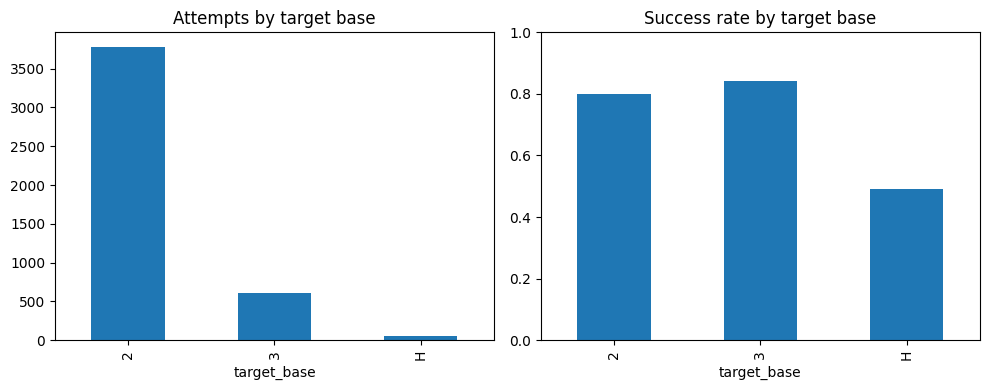

In [9]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
base_summary["attempts"].plot(kind="bar", ax=axes[0], title="Attempts by target base")
base_summary["success_rate"].plot(kind="bar", ax=axes[1], title="Success rate by target base", ylim=(0, 1))
plt.tight_layout()
plt.show()


## 7. Situational distribution — outs, inning, score — anything look broken?

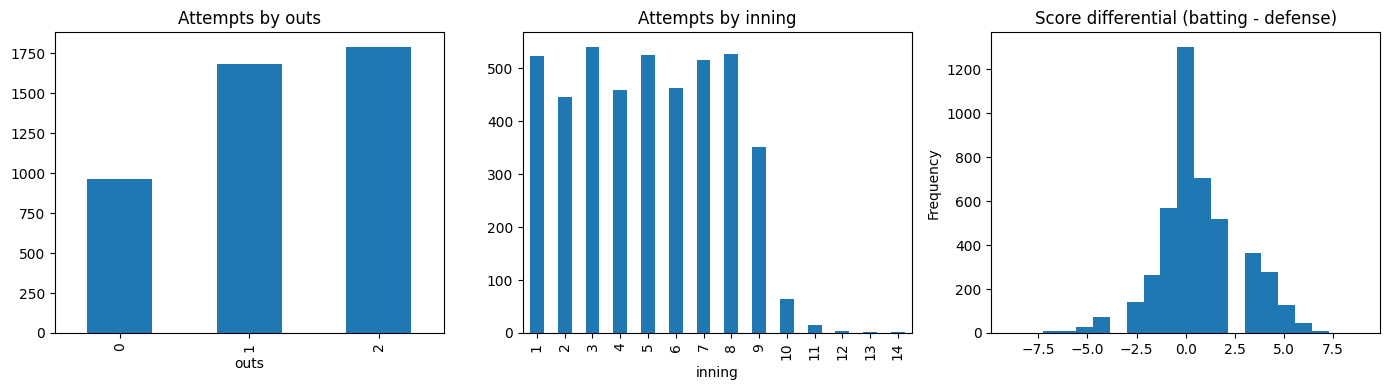

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
steals["outs"].value_counts().sort_index().plot(kind="bar", ax=axes[0], title="Attempts by outs")
steals["inning"].value_counts().sort_index().plot(kind="bar", ax=axes[1], title="Attempts by inning")
steals["score_diff"].plot(kind="hist", bins=21, ax=axes[2], title="Score differential (batting - defense)")
plt.tight_layout()
plt.show()


## 8. Multi-steal same-play snapshots (known, documented quirk)

The brief notes ~0.6% of attempts sit in same-play multi-steal snapshots
(e.g. a double steal where two runners go on the same pitch). Confirm the
rate is still in that ballpark and not something new.


In [11]:
dupe_plays = steals.groupby(["game_id", "inning", "half", "outs"]).size()
multi = (dupe_plays > 1).sum()
print(f"base-out states with >1 attempt logged: {multi} ({multi / len(dupe_plays):.2%} of state-groups)")


base-out states with >1 attempt logged: 329 (8.05% of state-groups)


## Summary

If every assertion above passed, the parsed 2023 steal-attempt table is
trustworthy: runners resolve cleanly, the league success rate and
individual leaderboard match known 2023 reality, and the situational
distributions (base, outs, inning) look like real baseball rather than a
parsing artifact. Next step from here is pulling more seasons
(`src/fetch_retrosheet.py`) and joining Statcast skill data
(`src/statcast_pull.py` + `src/id_crosswalk.py`) — not modeling yet.
